In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create an 8x3x8 neural network
model = Sequential([
    Dense(8, activation='relu', input_dim=8), # Input layer with 8 neurons
    Dense(3, activation='relu'), # Hidden layer with 3 neurons
    Dense(8, activation='sigmoid') # Output layer with 8 neurons
])

# Display the model summary
model.summary()

/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            32 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Note: you may need to restart the kernel to use updated packages.
==> Downloading https://mirrors.ustc.edu.cn/homebrew-bottles/api/formula.jws.jso
==> Downloading https://mirrors.ustc.edu.cn/homebrew-bottles/api/cask.jws.json
To reinstall 12.2.1, run:
  brew reinstall graphviz
digraph G {
rankdir=TB;
concentrate=true;
dpi=60;
splines=ortho;
node [shape=record];
6226566800 [label=<<table border="0" cellborder="1" bgcolor="black" cellpadding="10"><tr><td colspan="2" bgcolor="black"><font point-size="16" color="white"><b>dense_8</b> (Dense)</font></td></tr><tr><td bgcolor="white"><font point-size="14">Input shape: <b>(None, 8)</b></font></td><td bgcolor="white"><font point-size="14">Output shape: <b>(None, 8)</b></font></td></tr></table>>, fontname=Helvetica, border=0, margin=0];
6062609232 [label=<<table border="0" cellborder="1" bgcolor="black" cellpadding="10"><tr><td colspan="2" bgcolor="black"><font point-size="16" color="white"><b>dense_9</b> (Dense)</font></td></tr><tr><td bgcolor=

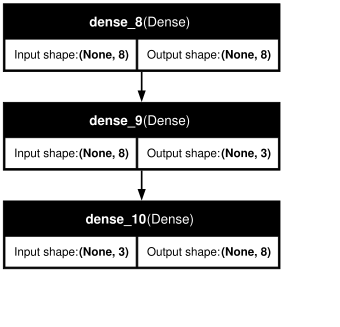

In [12]:
# 展示神经网络的形状结构
%pip install pydot graphviz

# Install the graphviz system package
import sys
import os

# Install graphviz based on the operating system
if sys.platform.startswith('darwin'):  # macOS
	!brew install graphviz || echo "Homebrew not available or graphviz already installed"
elif sys.platform.startswith('linux'):
	!apt-get update && apt-get install -y graphviz || echo "apt not available or graphviz already installed"
	# Alternative for other Linux distributions
	!yum install -y graphviz || echo "yum not available or graphviz already installed"

from IPython.display import SVG
from tensorflow.keras.utils import model_to_dot
dot = model_to_dot(model, show_shapes=True)
dot.set('dpi', '60')
print(dot)
SVG(dot.create(prog='dot', format='svg'))

In [13]:

# Compile the model
model.compile(optimizer='adam',
              loss='mse',
              metrics=['accuracy'])


In [14]:
import numpy as np

# 创建训练数据 - 每个输入是一个8维的one-hot向量
X_train = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])

# 输出数据与输入相同（恒等函数）
y_train = X_train.copy()

# 训练模型
history = model.fit(X_train, y_train, epochs=5000, verbose=0)

# 评估模型性能
loss, accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"最终损失：{loss:.4f}， 准确率：{accuracy:.4f}")

# 测试模型
predictions = model.predict(X_train)
print("\n预测结果：")
for i in range(len(X_train)):
    print(f"输入：{X_train[i]} -> 预测输出：{predictions[i]}，期望： {y_train[i]}")
    print("-" * 50)

最终损失：0.0009， 准确率：1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

预测结果：
输入：[1 0 0 0 0 0 0 0] -> 预测输出：[9.8932779e-01 3.8438298e-13 2.0175681e-11 2.1421800e-18 2.4873743e-02
 2.1679604e-18 5.1605110e-03 3.8065081e-03]，期望： [1 0 0 0 0 0 0 0]
--------------------------------------------------
输入：[0 1 0 0 0 0 0 0] -> 预测输出：[2.89736971e-14 9.89990175e-01 2.11480403e-23 9.79433209e-14
 1.01906825e-02 1.35070120e-03 3.39770681e-26 5.43721905e-03]，期望： [0 1 0 0 0 0 0 0]
--------------------------------------------------
输入：[0 0 1 0 0 0 0 0] -> 预测输出：[4.0145537e-13 3.9973972e-21 9.8758566e-01 4.7793160e-03 2.7272351e-02
 4.7150066e-12 2.4005007e-03 1.0467570e-21]，期望： [0 0 1 0 0 0 0 0]
--------------------------------------------------
输入：[0 0 0 1 0 0 0 0] -> 预测输出：[5.5531644e-21 2.1546344e-13 3.3683470e-03 9.8619699e-01 3.0464206e-02
 2.6401365e-03 4.3417571e-14 7.2851368e-22]，期望： [0 0 0 1 0 0 0 0]
--------------------------------------------------
输入：[0 0 0 0 1 0 0 0] -> 预测输出：[0.03348933 0.02771423 0.0